In [2]:
## HTML BASED LEARNING

In [1]:
# ───────────────────  ROBUST INGESTION  WITH  TWO  PARTS  ───────────────────
import re, os, concurrent.futures as cf, errno
from pathlib import Path
import pandas as pd
from urllib.parse import urlparse

BASE_DIR     = Path("data")
CSV_FILE     = BASE_DIR / "index.csv"
PART_DIRS    = [BASE_DIR / "dataset-part-1", BASE_DIR / "dataset-part-8"]
MAX_BYTES    = 1_000_000     # read at most 1 MB/file
MIN_HTML_LEN = 100
THREADS      = min(8, os.cpu_count() or 1)

_rx_style = re.compile(rb"<style[\s\S]*?</style>", re.I)

def fast_read(path: Path, limit=MAX_BYTES, retry=2) -> str:
    while retry >= 0:
        try:
            with path.open("rb") as f:
                raw = f.read(limit)
            return _rx_style.sub(b"", raw).decode("utf-8", "ignore")
        except (TimeoutError, OSError) as e:
            if isinstance(e, OSError) and e.errno not in (errno.EAGAIN, errno.ETIMEDOUT):
                break
            retry -= 1
    return ""

def domain_from_website(val: str) -> str:
    if "://" in val:
        dom = urlparse(val).netloc.split(":")[0].lower()
        return dom[4:] if dom.startswith("www.") else dom
    return ""

def parse_row(rec):
    html_path, site = rec
    html = fast_read(html_path)
    return {
        "raw_html":   html,
        "domain":     domain_from_website(site),
        "num_forms":  html.count("<form"),
        "num_inputs": html.count("<input"),
        "num_iframes":html.count("<iframe"),
        "num_links":  html.count("<a "),
        "html_len":   len(html)
    }

# 1) Load and filter CSV
labels = (
    pd.read_csv(CSV_FILE, usecols=["website", "result"])
      .rename(columns={"result": "target"})
)

# 2) resolve html_path from multiple part directories
def find_path(fname):
    for d in PART_DIRS:
        p = d / fname
        if p.exists():
            return p
    return None

labels["html_path"] = labels["website"].apply(find_path)
labels = labels[labels["html_path"].notnull()].reset_index(drop=True)
print(f"Using {len(labels)} pages found in parts 1 & 8")

# 3) parallel parse
with cf.ThreadPoolExecutor(max_workers=THREADS) as ex:
    rows = list(ex.map(parse_row,
                       labels[["html_path","website"]]
                       .itertuples(index=False, name=None),
                       chunksize=128))

df = pd.DataFrame(rows).join(labels["target"])

# 4) drop too-short pages
df = df[df["html_len"] >= MIN_HTML_LEN].reset_index(drop=True)
df.drop(columns="html_len", inplace=True)

# final dataset
data = df
print(f"Final dataset size: {len(data)} pages")
print("Label distribution:\n", data["target"].value_counts(normalize=True))
print("Average raw_html length:", data['raw_html'].str.len().mean())

Using 22305 pages found in parts 1 & 8
Final dataset size: 22083 pages
Label distribution:
 target
0    0.631436
1    0.368564
Name: proportion, dtype: float64
Average raw_html length: 91309.29226101526


In [2]:
from bs4 import BeautifulSoup
import re

suspicious_keywords = [
    "account", "bank", "confirm", "password", "login", "verify", 
    "credit card", "ssn", "social security", "urgent", "immediately", "click here"
]

def extract_features(html_content, page_domain=None):
    features = {}
    soup = BeautifulSoup(html_content, "html.parser")
    
    # Basic tag counts (existing features)
    features["num_forms"] = len(soup.find_all("form"))
    features["num_inputs"] = len(soup.find_all("input"))
    features["num_links"] = len(soup.find_all("a"))
    # Additional tag counts
    features["num_images"] = len(soup.find_all("img"))
    features["num_scripts"] = len(soup.find_all("script"))
    features["has_iframe"] = 1 if soup.find("iframe") else 0
    
    # Form-specific features
    features["num_password_inputs"] = len(soup.find_all("input", {"type": "password"}))
    features["num_text_inputs"] = len(soup.find_all("input", {"type": "text"}))
    features["form_empty_action"] = 0
    features["form_external_action"] = 0
    features["form_mailto"] = 0
    for form in soup.find_all("form"):
        action = (form.get("action") or "").lower()
        if action == "" or action == "about:blank":
            features["form_empty_action"] = 1
        if action.startswith("mailto:"):
            features["form_mailto"] = 1
        if page_domain:
            # If action is absolute URL, check domain mismatch
            if action.startswith("http"):
                # extract domain from action
                domain_match = re.search(r'://([^/]+)', action)
                if domain_match:
                    action_domain = domain_match.group(1)
                    if page_domain not in action_domain:
                        features["form_external_action"] = 1
    
    # Link-based features
    features["num_ext_links"] = 0
    features["has_ip_link"] = 0
    features["has_at_sign_link"] = 0
    for a in soup.find_all("a", href=True):
        href = a['href'].lower()
        # Count external links if page_domain is known
        if page_domain:
            if href.startswith("http") and page_domain not in href:
                features["num_ext_links"] += 1
        # Check for IP address in URL
        if re.search(r"http[s]?://\d+\.\d+\.\d+\.\d+", href):
            features["has_ip_link"] = 1
        if "@" in href and not href.startswith("mailto:"):
            features["has_at_sign_link"] = 1
    # If domain known, also add ratio of external links
    if page_domain and features["num_links"] > 0:
        features["ext_link_ratio"] = features["num_ext_links"] / features["num_links"]
    else:
        features["ext_link_ratio"] = 0.0
    
    # Suspicious script or attribute features
    html_text = str(soup)  # full HTML as text for pattern checks
    features["has_popup_script"] = 1 if re.search(r"window\.open\s*\(", html_text, flags=re.IGNORECASE) else 0
    features["has_onmouseover_status"] = 1 if re.search(r"onmouseover\s*=\s*\"[^\"]*window\.status", html_text, flags=re.IGNORECASE) else 0
    features["has_disable_right_click"] = 1 if ("oncontextmenu" in html_text or "preventDefault" in html_text) else 0
    features["has_meta_refresh"] = 1 if re.search(r"<meta[^>]*http-equiv\s*=\s*\"refresh\"", html_text, flags=re.IGNORECASE) else 0
    

    # Suspicious keyword counts in visible text
    page_text = soup.get_text(separator=" ").lower()
    keyword_count = 0
    for word in suspicious_keywords:
        if word in page_text:
            keyword_count += 1
            features[f"kw_{word.replace(' ', '_')}"] = 1  # binary flag for each keyword (optional)
        else:
            features[f"kw_{word.replace(' ', '_')}"] = 0

    features["suspicious_keyword_count"] = keyword_count
    page_text = soup.get_text(separator=" ").lower()

    return features, page_text

# Example usage on one HTML page (assuming we have page_domain separately if possible):
# html = open("sample_page.html").read()
# feats = extract_features(html, page_domain="example.com")
# print(feats)


In [4]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Prepare data for vectorization
html_texts = []    # list of page texts
feature_list = []  # list of feature dicts
page_domains = []  # list of page domains if available
feature_rows = []

# Assume we have a list of HTML pages data
for html, dom in zip(data["raw_html"], data["domain"]):
    feats, text = extract_features(html, page_domain=dom or None)
    feature_rows.append(list(feats.values()))
    html_texts.append(text)

# Convert feature_list (list of lists) to array
X_struct = np.array(feature_rows, dtype=np.float32)  # shape (n_samples, n_manual_features)
y        = data["target"].values

# Set up TF-IDF with word and bigram features (and possibly char ngrams)
vectorizer = TfidfVectorizer(
    lowercase=True, 
    strip_accents='unicode',
    analyzer='word',
    ngram_range=(1, 2),         # unigrams and bigrams
    max_features=5000,          # limit vocab size for model compactness
    stop_words='english'        # (optional) remove very common English words
)
X_text = vectorizer.fit_transform(html_texts)

# (Optional) character n-gram TF-IDF for additional patterns
char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=2000
)
X_char = char_vectorizer.fit_transform(html_texts)

# Combine all features: manual structural + text tfidf (+ char tfidf)
X_all = hstack([X_struct, X_text, X_char])  # final feature matrix
y = data["target"].values 

print("Feature matrix shape:", X_all.shape)
print("TF-IDF vocab size:", len(vectorizer.vocabulary_))


KeyboardInterrupt: 

In [5]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score

# Split data into train/validation (assuming we want a hold-out validation for threshold tuning)
X_train, X_val, y_train, y_val = train_test_split(X_all, y, test_size=0.2, stratify=y, random_state=42)

# Define models with balanced settings
xgb_clf = xgb.XGBClassifier(
    max_depth=4, 
    n_estimators=100, 
    learning_rate=0.1,
    subsample=0.8, 
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=(sum(y_train==0) / sum(y_train==1))  # balance positive class weight if needed
)
lr_clf = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)

# Train models
xgb_clf.fit(X_train, y_train)
lr_clf.fit(X_train, y_train)

# Evaluate on validation set
probs = xgb_clf.predict_proba(X_val)[:,1]
base_auc = roc_auc_score(y_val, probs)
base_f1 = f1_score(y_val, (probs >= 0.5).astype(int))
print(f"XGBoost Validation ROC-AUC: {base_auc:.3f}, F1 (0.5 thresh): {base_f1:.3f}")

# Find optimal threshold for F1 on XGBoost
best_thresh, best_f1 = 0.5, base_f1
for t in np.linspace(0.1, 0.9, 81):  # search between 0.1 and 0.9
    f1 = f1_score(y_val, (probs >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_thresh = f1, t
print(f"Optimal probability threshold = {best_thresh:.2f}, F1 = {best_f1:.3f}")

# Final evaluation at optimal threshold
final_preds = (probs >= best_thresh).astype(int)
precision   = precision_score(y_val, final_preds)
recall      = recall_score(y_val, final_preds)
print(f"Precision: {precision:.3f}, Recall: {recall:.3f} on validation")

# (Optional) Cross-validate ROC-AUC for robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(xgb_clf, X_all, y, cv=cv, scoring='roc_auc')
cv_f1 = cross_val_score(xgb_clf, X_all, y, cv=cv, scoring='f1')
print(f"5-fold CV ROC-AUC: {cv_auc.mean():.3f}, F1: {cv_f1.mean():.3f}")


NameError: name 'X_all' is not defined

In [6]:
# ===============================================================
#  STATIC-HTML PHISHING DETECTOR – FAST TRAIN WITH EARLY STOPPING
#  (uses xgb.train to enable early stopping in older XGBoost versions)
#  * tree_method="hist" for speed
#  * Reduced hashing dims (2**17 + 2**16)
#  * Single hold-out split + early stopping
# ===============================================================
import re, math, time, gc
import numpy as np, pandas as pd
from bs4 import BeautifulSoup
from collections import Counter
from urllib.parse import urlparse
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, classification_report
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix, hstack
import xgboost as xgb

# 1. helper regex + keywords
_rx_ip      = re.compile(r"https?://\d{1,3}(?:\.\d{1,3}){3}")
_rx_base64  = re.compile(r"[A-Za-z0-9+/]{40,}={0,2}")
_rx_js_eval = re.compile(r"\b(eval|atob|document\.write|innerHTML\s*=)\b", re.I)
susp_kw     = [
    "account","bank","confirm","password","login","verify",
    "credit card","ssn","social security","urgent",
    "immediately","click here","update"
]

def shannon_entropy(s: str) -> float:
    if not s: return 0.0
    cnt = Counter(s)
    p   = np.fromiter(cnt.values(), dtype=float) / len(s)
    return float(-(p * np.log2(p)).sum())

def extract(html: str, dom: str):
    # parse HTML & JS
    soup    = BeautifulSoup(html, "html.parser")
    text    = soup.get_text(" ").lower()
    js_text = " ".join(t.get_text(" ") for t in soup.find_all("script")).lower()
    # basic counts
    feat = {
        "forms": len(soup.find_all("form")),
        "inputs": len(soup.find_all("input")),
        "iframes": len(soup.find_all("iframe")),
        "links": len(soup.find_all("a")),
        "imgs": len(soup.find_all("img")),
        "scripts": len(soup.find_all("script")),
        "html_len": len(html),
        "js_len": len(js_text),
        "entropy": shannon_entropy(html[:20000]),
        "js_eval_cnt": len(_rx_js_eval.findall(js_text)),
        "base64_cnt": len(_rx_base64.findall(js_text)),
        "link_ip": int(bool(_rx_ip.search(html))),
        "link_at": int(bool(re.search(r"https?://[^ ]+@", html))),
        "kw_cnt": sum(w in text for w in susp_kw)
    }
    # derived features
    feat["inputs_per_form"] = feat["inputs"] / max(feat["forms"], 1)
    feat["iframe_ratio"]    = feat["iframes"] / max(feat["links"]+1, 1)
    feat["js_html_ratio"]   = feat["js_len"] / max(feat["html_len"], 1)
    # external link & form-action
    feat["ext_link_ratio"]  = 0.0
    feat["form_ext_action"] = 0
    if dom:
        dom = dom.lower()
        ext = sum(
            1 for a in soup.find_all("a", href=True)
            if a["href"].lower().startswith("http") and dom not in a["href"].lower()
        )
        feat["ext_link_ratio"] = ext / max(feat["links"], 1)
        for f in soup.find_all("form"):
            act = (f.get("action") or "").lower()
            if act.startswith("http") and dom not in act:
                feat["form_ext_action"] = 1
                break
    return feat, text + " " + js_text

# 2. build feature matrix
start_time = time.time()
numeric_rows, corpus = [], []
for html, dom in zip(data["raw_html"], data["domain"]):
    feats, txt = extract(html, dom or "")
    numeric_rows.append(list(feats.values()))
    corpus.append(txt)
X_num = np.asarray(numeric_rows, dtype=np.float32)
y     = data["target"].values
del numeric_rows; gc.collect()

# 3. hashing vectorizers
hv_word = HashingVectorizer(analyzer="word", ngram_range=(1,2),
                            n_features=2**17, strip_accents="unicode",
                            alternate_sign=False, norm=None)
hv_char = HashingVectorizer(analyzer="char", ngram_range=(4,6),
                            n_features=2**16, alternate_sign=False, norm=None)
X_all = hstack([
    csr_matrix(X_num),
    hv_word.transform(corpus),
    hv_char.transform(corpus)
], format="csr")
print(f"Feature build: {time.time()-start_time:.1f}s  shape={X_all.shape}")

# 4. train/val split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)

# 5. prepare DMatrix
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.08,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "scale_pos_weight": float((y_tr==0).sum()/(y_tr==1).sum()),
    "tree_method": "hist"
}

# 6. train with early stopping
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1200,
    evals=[(dval, "val")],
    early_stopping_rounds=40,
    verbose_eval=False
)
print("Best iteration:", bst.best_iteration)

# 7. validation metrics
proba = bst.predict(dval)
auc   = roc_auc_score(y_val, proba)
prec, rec, thr = precision_recall_curve(y_val, proba)
f1   = 2*prec*rec/(prec+rec+1e-9)
best = np.nanargmax(f1)
opt_thr, opt_f1 = thr[best], f1[best]
print(f"Val ROC-AUC: {auc:.3f}  F1@0.50: {f1_score(y_val, (proba>=0.5).astype(int)):.3f}")
print(f"Optimal F1 {opt_f1:.3f} at thr {opt_thr:.2f}")

# 8. hold-out report
preds = (proba >= opt_thr).astype(int)
print("\nHold-out classification report:")
print(classification_report(y_val, preds, digits=3))

print(f"\nTotal pipeline time: {time.time()-start_time:.1f}s")


Feature build: 890.5s  shape=(22083, 196627)
Best iteration: 812
Val ROC-AUC: 0.991  F1@0.50: 0.940
Optimal F1 0.944 at thr 0.65

Hold-out classification report:
              precision    recall  f1-score   support

           0      0.961     0.975     0.968      2789
           1      0.956     0.932     0.944      1628

    accuracy                          0.959      4417
   macro avg      0.958     0.953     0.956      4417
weighted avg      0.959     0.959     0.959      4417


Total pipeline time: 3034.4s



Top Numeric Feature Importances:
            feature       gain
3             links  40.445431
14  inputs_per_form  35.252533
1            inputs  30.101032
2           iframes  14.310810
5           scripts   8.926315
0             forms   8.495848
4              imgs   6.267857
15     iframe_ratio   4.130845
7            js_len   4.123665
13           kw_cnt   2.762237
6          html_len   2.161359
16    js_html_ratio   2.112161
8           entropy   1.268780
12          link_at   0.779347
9       js_eval_cnt   0.768807


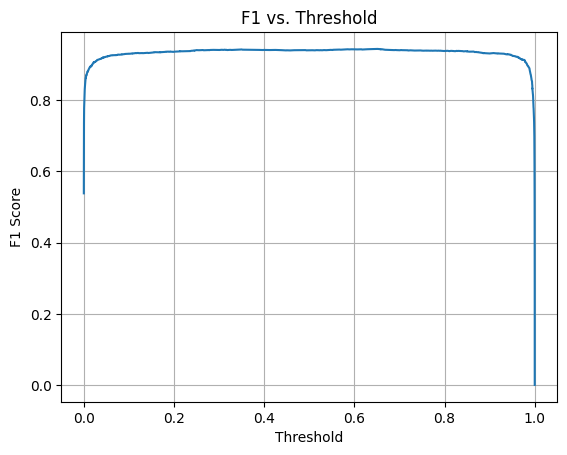

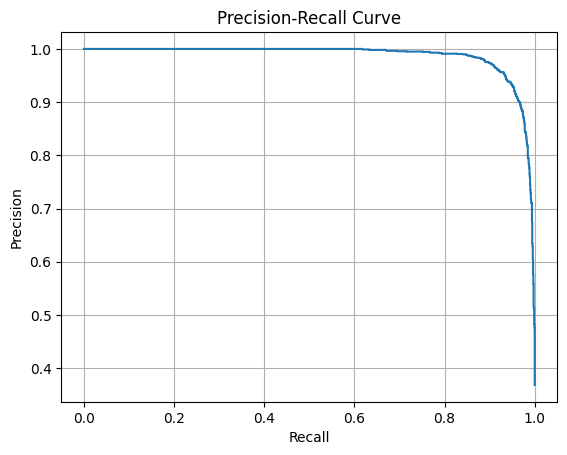

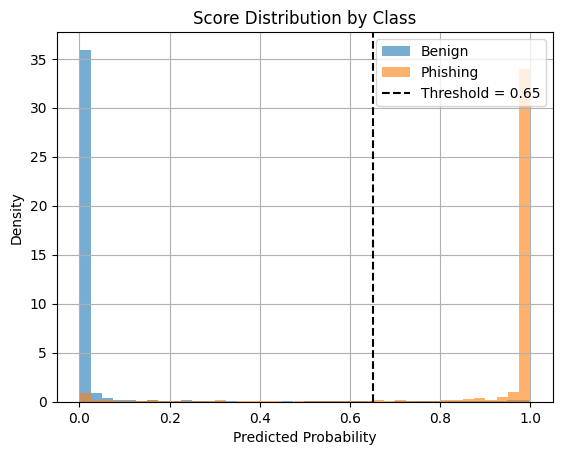

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# ---------- 1. Top numeric feature importances ----------
num_cols = list(extract("", "")[0].keys())
imp_dict = bst.get_score(importance_type="gain")
imp_list = [(col, imp_dict.get(f"f{i}", 0.0)) for i, col in enumerate(num_cols)]
imp_df   = pd.DataFrame(imp_list, columns=["feature", "gain"]).sort_values("gain", ascending=False)
print("\nTop Numeric Feature Importances:")
print(imp_df.head(15))

# ---------- 2. F1 vs threshold sweep ----------
prec, rec, thr = precision_recall_curve(y_val, proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)

plt.figure()
plt.plot(thr, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs. Threshold")
plt.grid(True)
plt.show()

# ---------- 3. Precision-Recall Curve ----------
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# ---------- 4. Score distribution ----------
plt.figure()
plt.hist(proba[y_val==0], bins=40, alpha=0.6, label="Benign", density=True)
plt.hist(proba[y_val==1], bins=40, alpha=0.6, label="Phishing", density=True)
plt.axvline(opt_thr, color="black", linestyle="--", label=f"Threshold = {opt_thr:.2f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Score Distribution by Class")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# ==========================================================
#   EXPORT  THE  FINAL  PHISHING  DETECTOR
#   • retrain on the *full* dataset using best_iter trees
#   • save Booster, hashing vectorisers, numeric-feature order,
#     and tuned probability threshold
# ==========================================================
import pickle, joblib, os, json, xgboost as xgb
from pathlib import Path

ARTIFACT_DIR = Path("model_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# 1)  Re-train on ALL data up to best_iteration
full_dtrain = xgb.DMatrix(X_all, label=y)
final_params       = params.copy()
best_round         = bst.best_iteration               # from previous cell
final_booster      = xgb.train(final_params,
                               full_dtrain,
                               num_boost_round=best_round)

# 2)  Save the XGBoost model
model_path = ARTIFACT_DIR / "phish_xgb.json"
final_booster.save_model(model_path)

# 3)  Save the hashing vectorisers and numeric feature order
joblib.dump(hv_word, ARTIFACT_DIR / "hv_word.joblib")
joblib.dump(hv_char, ARTIFACT_DIR / "hv_char.joblib")
with open(ARTIFACT_DIR / "num_cols.json", "w") as f:
    json.dump(list(extract("", "")[0].keys()), f)

# 4)  Save the tuned probability threshold
with open(ARTIFACT_DIR / "threshold.txt", "w") as f:
    f.write(f"{opt_thr:.4f}\n")

# 5)  Quick summary
total_bytes = sum(p.stat().st_size for p in ARTIFACT_DIR.iterdir())
print(f"Saved model + assets to {ARTIFACT_DIR}  (≈ {total_bytes/1024:.1f} KB)")
print("Files:")
for p in ARTIFACT_DIR.iterdir():
    print(" •", p.name)


Saved model + assets to model_artifacts  (≈ 2251.3 KB)
Files:
 • threshold.txt
 • hv_word.joblib
 • num_cols.json
 • hv_char.joblib
 • phish_xgb.json
